# Experiment 5: Objective Values at Iteration Milestones

Compare PALM and FISTA-PALM at fixed iteration milestones.

**Setup**
- Matrix sizes: $100 \times 80$, $500 \times 200$, and $1000 \times 600$
- Ranks: $r = 10$, $r = 50$, and $r = 200$
- Sparsity levels in $Y$: $10\%$, $25\%$, and $33\%$
- Milestones: $25$, $100$, $250$, and $500$ iterations

**Goal**

Evaluate how quickly each method reduces the objective at fixed iteration checkpoints.

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.solvers.palm import PALM
from src.solvers.fista_palm import FISTAPALM

from src.utils.data import generate_low_rank_matrix_problem, get_milestone_value
from src.utils.problem_factory import make_matrix_factorisation_problem
from src.utils.io import make_fig_path, save_table
from src.utils.plotting import plot_milestone_grid

In [8]:
np.random.seed(42)

matrix_configs = [
    (100, 80, 10),
    (500, 200, 50),
    (1000, 600, 200),
]

sparsity_levels = [0.10, 0.25, 0.33]
milestones = [25, 100, 250, 500, 750, 1000]
max_iter = max(milestones)
gamma = 1.2

solvers = {
    "PALM": PALM(max_iter=max_iter),
    "FISTA-PALM": FISTAPALM(max_iter=max_iter),
}

## Run milestone comparison

Run each solver up to $500$ iterations and extract objective values at fixed checkpoints.

In [9]:
records = []

for m, n, r in matrix_configs:
    for sparsity in sparsity_levels:
        A, X0, Y0, _, _ = generate_low_rank_matrix_problem(
            m, n, r, sparsity=sparsity, seed=42
        )

        problem = make_matrix_factorisation_problem(
            A, r, sparsity, gamma=gamma
        )

        for method_name, solver in solvers.items():
            _, _, hist = solver.solve(problem, X0.copy(), Y0.copy())

            row = {
                "Matrix": f"{m}x{n}",
                "m": m,
                "n": n,
                "rank": r,
                "Sparsity": f"{int(sparsity * 100)}%",
                "Method": method_name,
            }

            for k in milestones:
                row[f"Iter {k}"] = get_milestone_value(hist, k)

            records.append(row)

## Milestone table

Objective values at selected iteration checkpoints.

In [10]:
df = pd.DataFrame(records)

params = {
    "configs": len(matrix_configs),
    "slevels": len(sparsity_levels),
    "maxiter": max_iter,
}

save_table(
    df,
    ROOT,
    "milestone_objectives",
    params,
)

df

,Matrix,m,n,rank,Sparsity,Method,Iter 25,Iter 100,Iter 250,Iter 500,Iter 750,Iter 1000
0,100x80,100,80,10,10%,PALM,7.150635e+03,7.135109e+03,7134.843034,7134.383273,7133.897595,7133.388946
1,100x80,100,80,10,10%,FISTA-PALM,7.135865e+03,6.792020e+03,3338.022177,1062.068993,1049.614168,1049.614168
2,100x80,100,80,10,25%,PALM,2.357136e+02,2.274849e+02,224.694326,219.642912,214.259481,208.828418
3,100x80,100,80,10,25%,FISTA-PALM,2.277161e+02,2.034141e+02,117.810240,93.051867,93.051867,93.051867
4,100x80,100,80,10,33%,PALM,2.279503e+02,2.219973e+02,211.690196,190.735201,168.293151,149.843311
5,100x80,100,80,10,33%,FISTA-PALM,2.221943e+02,1.455756e+02,74.817133,58.176213,57.672015,57.672015
6,500x200,500,200,50,10%,PALM,4.369144e+04,1.247284e+04,12445.029390,12415.021969,12384.912383,12354.714777
7,500x200,500,200,50,10%,FISTA-PALM,1.358232e+04,1.230661e+04,11514.739462,9674.971035,8480.585426,7687.277899
8,500x200,500,200,50,25%,PALM,3.574009e+04,1.303491e+04,12342.633483,12057.797336,11767.260621,11472.031673
9,500x200,500,200,50,25%,FISTA-PALM,1.311603e+04,1.109007e+04,7069.633578,4327.827589,3439.063500,3024.203215


## Milestone objective curves

Objective values at fixed iteration checkpoints for each matrix size.

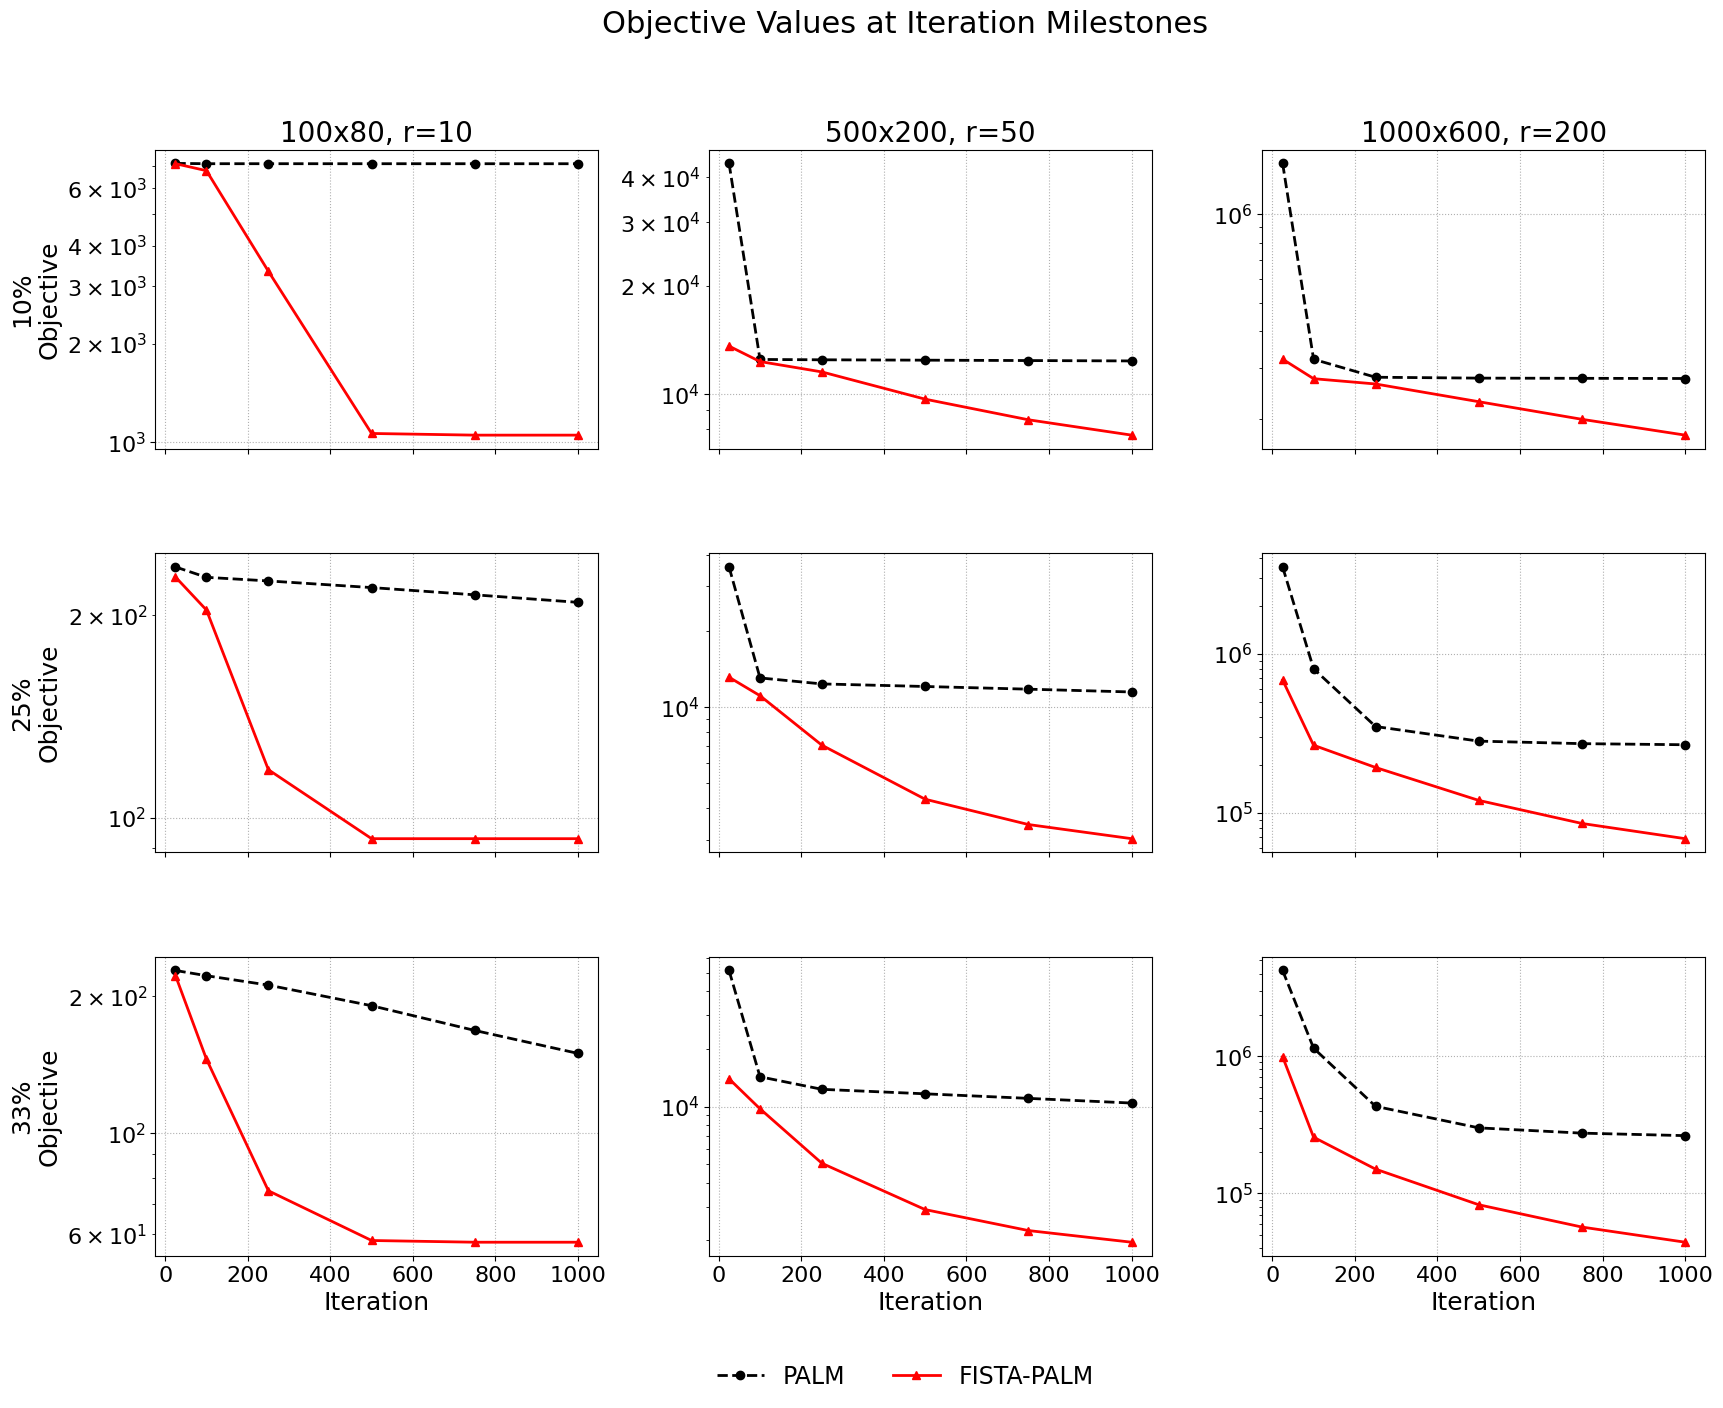

In [11]:
plot_milestone_grid(
    df,
    matrix_configs,
    sparsity_levels,
    milestones,
    save_path=make_fig_path(ROOT, "milestone_objectives_grid", params),
)

## Observations

- FISTA-PALM consistently outperforms PALM at all milestones, with lower objective values from as early as $25$ iterations.

- The advantage of FISTA-PALM is most pronounced in early and intermediate stages ($25$–$250$ iterations), where PALM often plateaus while FISTA-PALM continues decreasing.

- For larger matrices, the gap becomes more significant:
  - PALM shows slow decay and early stagnation  
  - FISTA-PALM maintains steady improvement across all milestones  

- At higher sparsity levels ($25\%$, $33\%$), the difference is even clearer, with PALM converging much more slowly.

- Extending to later milestones ($750$, $1000$) shows that:
  - PALM continues to decrease only marginally  
  - FISTA-PALM still makes noticeable progress, especially on larger problems  

- The milestone grid highlights that iteration efficiency—not just final value—is the key advantage of FISTA-PALM.